In [1]:
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.autograd import Variable

import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils

import numpy as np

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)

cuda:0


In [3]:
# Batch size during training
batch_size = 100

num_workers = 2

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 32

# Number of training epochs
num_epochs = 100

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.9

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

In [4]:
class generator(nn.Module):

    #generator model
    def __init__(self,in_channels):
        super(generator,self).__init__()
        self.fc1=nn.Linear(in_channels,384)

        self.t1=nn.Sequential(
            nn.ConvTranspose2d(in_channels=384,out_channels=192,kernel_size=(4,4),stride=1,padding=0),
            nn.BatchNorm2d(192),
            nn.ReLU()
        )
        self.t2=nn.Sequential(
            nn.ConvTranspose2d(in_channels=192,out_channels=96,kernel_size=(4,4),stride=2,padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU()
        )
        self.t3=nn.Sequential(
            nn.ConvTranspose2d(in_channels=96,out_channels=48,kernel_size=(4,4),stride=2,padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU()
        )
        self.t4=nn.Sequential(
            nn.ConvTranspose2d(in_channels=48,out_channels=3,kernel_size=(4,4),stride=2,padding=1),
            nn.Tanh()
        )

    def forward(self,x):
    	x=x.view(-1,110)
    	x=self.fc1(x)
    	x=x.view(-1,384,1,1)
    	x=self.t1(x)
    	x=self.t2(x)
    	x=self.t3(x)
    	x=self.t4(x)
    	return x #output of generator

In [5]:
gen = generator(110).cuda() # we do not specify ``weights``, i.e. create untrained model
gen.load_state_dict(torch.load('gen.pth', weights_only=True))

<All keys matched successfully>

In [6]:
# CIFAR10 dataset
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=num_workers)

testset = datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=num_workers)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


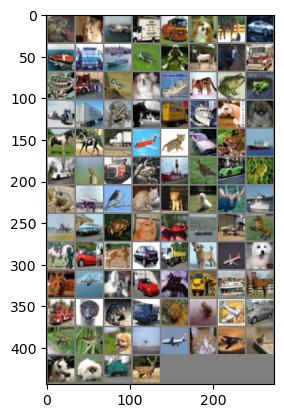

frog  cat   ship  truck truck dog   horse car   ship  truck ship  cat   frog  horse bird  truck frog  truck bird  dog   ship  cat   frog  frog  truck truck frog  cat   truck ship  horse dog   horse horse truck plane cat   car   frog  ship  car   bird  truck frog  ship  bird  car   frog  frog  plane bird  cat   cat   dog   deer  ship  plane plane frog  cat   frog  ship  plane horse horse car   deer  car   truck dog   plane dog   cat   plane cat   car   cat   truck ship  horse truck bird  frog  truck cat   frog  plane car   deer  bird  dog   plane plane cat   plane bird  horse dog   truck deer 


In [7]:
# sampling CIFAR10 images
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# sample images from training dataset
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images and labels
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [8]:
# Model definition for CIFAR10
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 5)
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 12 * 12, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv1(x) # 28 * 28
        x = F.relu(x)
        x = self.conv2(x) # 24 * 24
        x = F.relu(x)
        x = self.pool(x) # 12 * 12
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

In [9]:
num_images = 50000

In [10]:
images_list = []
labels_list = []

for i in range(int(num_images / batch_size)):

    aug_noise = torch.FloatTensor(batch_size, 110, 1, 1).normal_(0, 1)
    aug_noise_ = np.random.normal(0, 1, (batch_size, 110))
    aug_label = np.random.randint(0, 10, batch_size)
    aug_onehot = np.zeros((batch_size, 10))
    aug_onehot[np.arange(batch_size), aug_label] = 1
    aug_noise_[np.arange(batch_size), :10] = aug_onehot[np.arange(batch_size)]
    aug_noise_ = (torch.from_numpy(aug_noise_))
    aug_noise.data.copy_(aug_noise_.view(batch_size, 110, 1, 1))
    aug_noise=aug_noise.cuda()

    aug_image = gen(aug_noise)

    for j in range(batch_size):
        images_list.append(aug_image[j])
        labels_list.append(aug_label[j])

In [11]:
class GeneratedDataset(torch.utils.data.Dataset):
    def __init__(self, images_list, labels_list, transform=None, target_transform=None):
        self.images = images_list
        self.labels = labels_list
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [12]:
dataset = GeneratedDataset(images_list, labels_list)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=100,
                                          shuffle=True)

In [13]:
aug_net = Net()
aug_net.to(device)

Net(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [14]:
# loss function and optimization function for CIFAR10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(aug_net.parameters(), lr=lr)

In [15]:
# CIFAR10 Training
for epoch in range(num_epochs):  # loops over dataset

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data[0].to(device), data[1].to(device)
        
        # initialize gradiants to zero
        optimizer.zero_grad()

        # forward, backward
        outputs = aug_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 200 == 199:    # batch size=100, so 600 batch calls for training data
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0
    
    running_loss = 0.0
    for i, data in enumerate(dataloader, 0):
        # get the inputs
        with torch.no_grad():
            inputs, labels = data[0].to(device).detach(), data[1].to(device)

        labels = labels.to(torch.long)
        
        # initialize gradiants to zero
        optimizer.zero_grad()

        # forward, backward
        outputs = aug_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 200 == 199:    # batch size=100, so 600 batch calls for training data
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,   200] loss: 0.186
[1,   400] loss: 0.157
[1,   200] loss: 0.234
[1,   400] loss: 0.230
[2,   200] loss: 0.157
[2,   400] loss: 0.139
[2,   200] loss: 0.233
[2,   400] loss: 0.229
[3,   200] loss: 0.143
[3,   400] loss: 0.126
[3,   200] loss: 0.233
[3,   400] loss: 0.229
[4,   200] loss: 0.131
[4,   400] loss: 0.114
[4,   200] loss: 0.232
[4,   400] loss: 0.229
[5,   200] loss: 0.121
[5,   400] loss: 0.107
[5,   200] loss: 0.232
[5,   400] loss: 0.228
[6,   200] loss: 0.111
[6,   400] loss: 0.101
[6,   200] loss: 0.231
[6,   400] loss: 0.228
[7,   200] loss: 0.104
[7,   400] loss: 0.095
[7,   200] loss: 0.231
[7,   400] loss: 0.228
[8,   200] loss: 0.098
[8,   400] loss: 0.090
[8,   200] loss: 0.231
[8,   400] loss: 0.228
[9,   200] loss: 0.093
[9,   400] loss: 0.084
[9,   200] loss: 0.230
[9,   400] loss: 0.228
[10,   200] loss: 0.087
[10,   400] loss: 0.080
[10,   200] loss: 0.230
[10,   400] loss: 0.227
[11,   200] loss: 0.082
[11,   400] loss: 0.077
[11,   200] loss: 0.229
[11,

In [16]:
# accuracy testing
correct = 0
total = 0

with torch.no_grad(): # testing, no gradient update
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        # only run forward
        outputs = aug_net(images)
        # the highest energy class = prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of augmented image classifier on CIFAR10 test images: {100 * correct // total} %')

Accuracy of augmented image classifier on CIFAR10 test images: 58 %
